In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('images', exist_ok=True)

tickers = {
    'JPM': 'JP Morgan',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Google',
    'BRK-B': 'Berkshire Hathaway',
    'JNJ': 'Johnson & Johnson',
    'XOM': 'Exxon Mobil'
}

df = yf.download(list(tickers.keys()), start='2020-01-01', end='2024-12-31')['Close']
df.columns = [tickers[col] for col in df.columns]
df = df.fillna(method='ffill')
returns = df.pct_change().dropna()
print("데이터 로드 완료!")
print(f"종목 수: {len(df.columns)}, 기간: {df.index[0].date()} ~ {df.index[-1].date()}")

[*********************100%***********************]  7 of 7 completed

데이터 로드 완료!
종목 수: 7, 기간: 2020-01-02 ~ 2024-12-30



C:\Users\playdata2\AppData\Local\Temp\ipykernel_16908\705420957.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


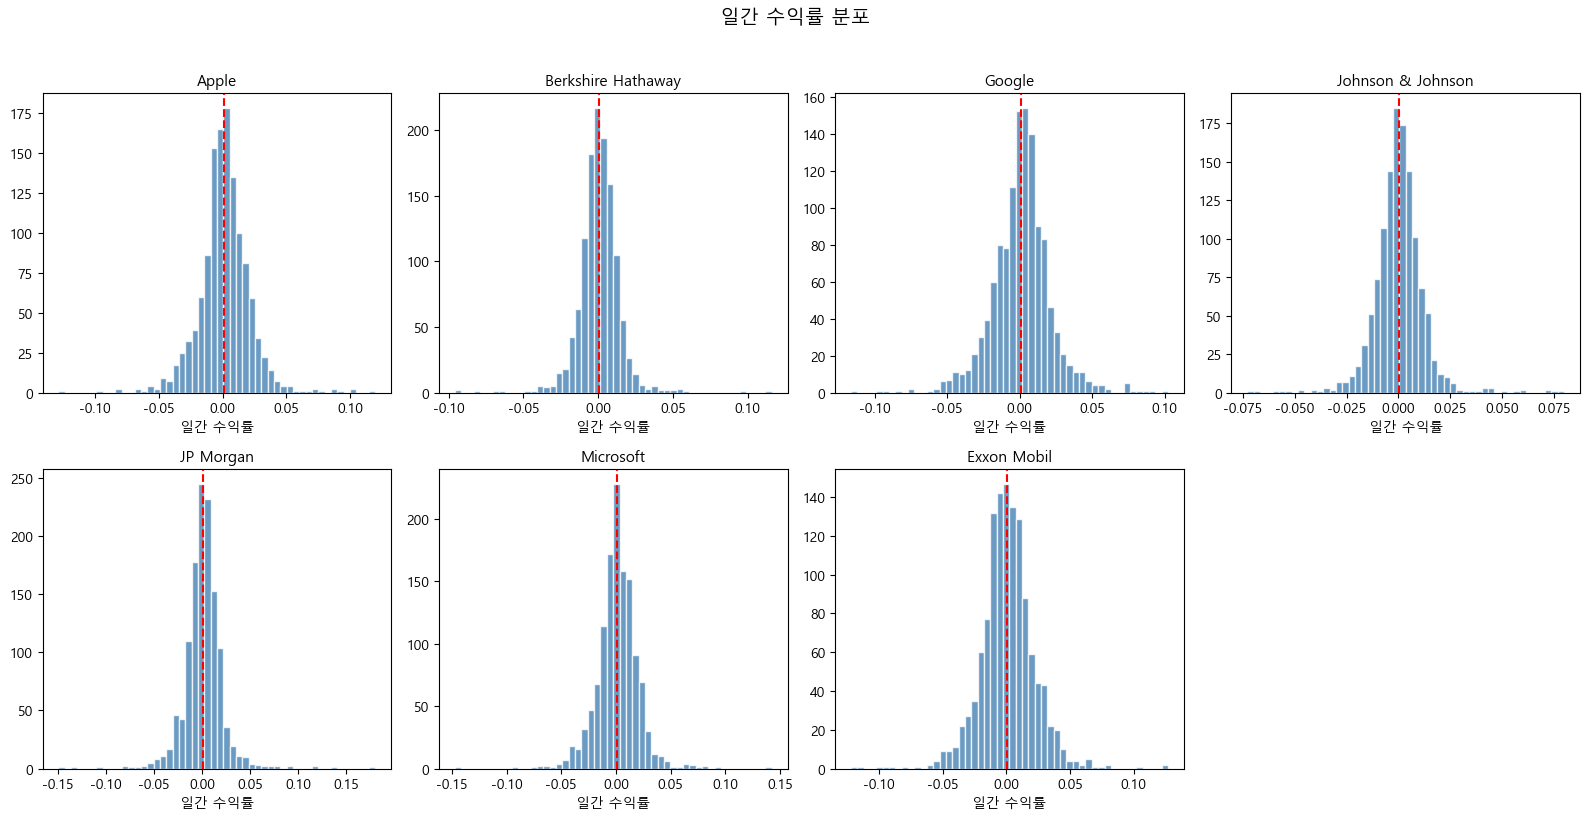

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(returns.columns):
    axes[i].hist(returns[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(returns[col].mean(), color='red', linestyle='--', label='평균')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('일간 수익률')

if len(returns.columns) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('일간 수익률 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('images/return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

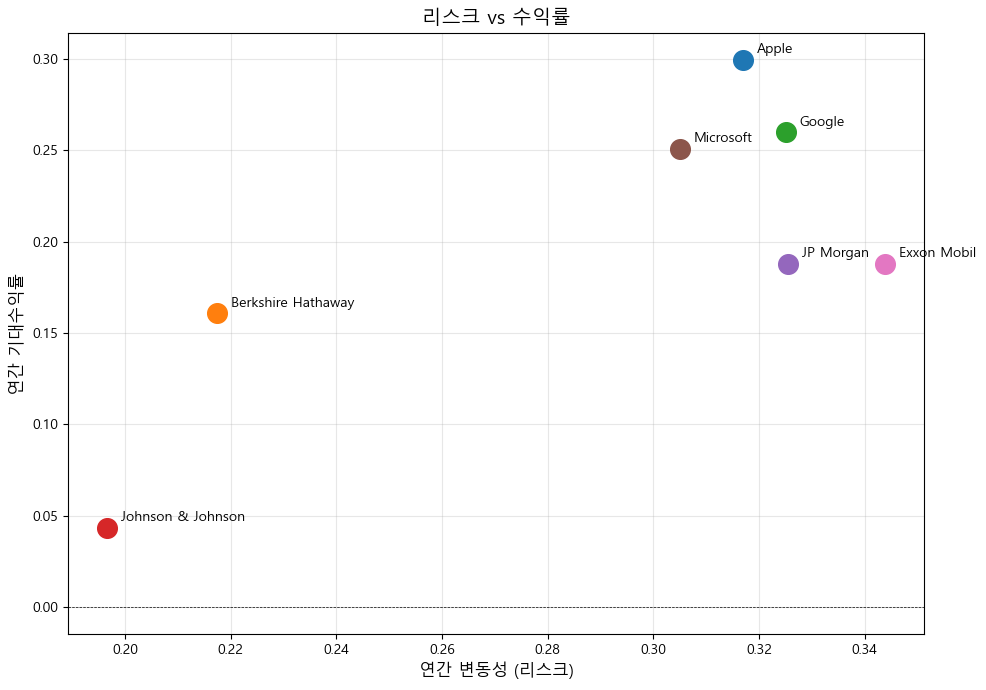

In [3]:
annual_returns = returns.mean() * 252
annual_vol = returns.std() * np.sqrt(252)

plt.figure(figsize=(10, 7))
for i, stock in enumerate(annual_returns.index):
    plt.scatter(annual_vol[stock], annual_returns[stock], s=200, zorder=5)
    plt.annotate(stock,
                 (annual_vol[stock], annual_returns[stock]),
                 textcoords="offset points",
                 xytext=(10, 5), fontsize=10)

plt.xlabel('연간 변동성 (리스크)', fontsize=12)
plt.ylabel('연간 기대수익률', fontsize=12)
plt.title('리스크 vs 수익률', fontsize=14)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

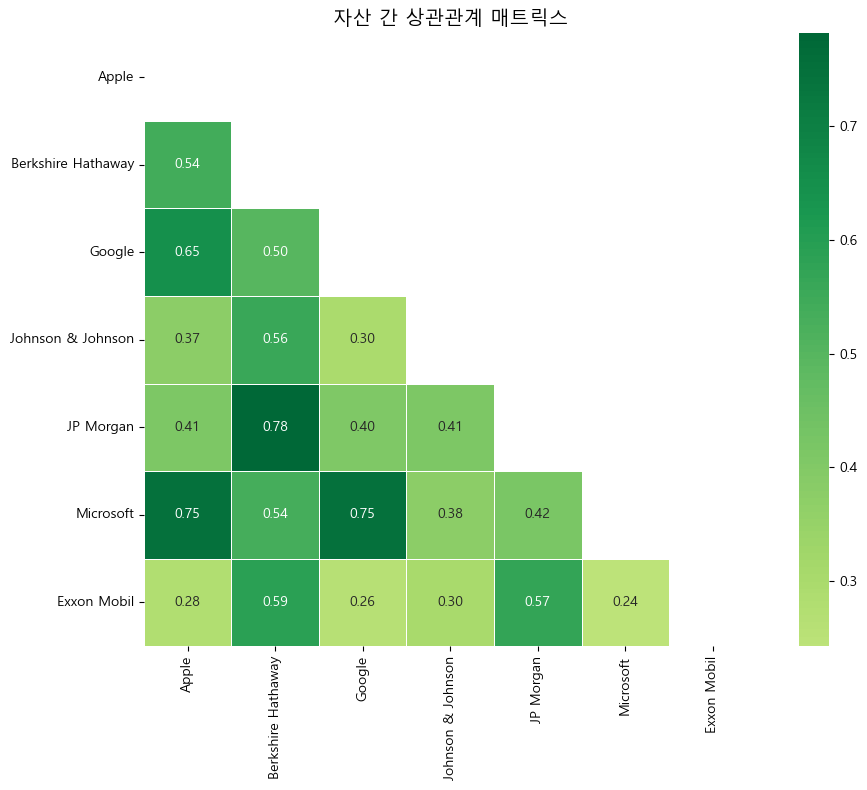

In [4]:
plt.figure(figsize=(10, 8))
corr = returns.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            mask=mask)
plt.title('자산 간 상관관계 매트릭스', fontsize=14)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

=== Sharpe Ratio 순위 ===
Apple                 0.7875
Microsoft             0.6579
Google                0.6455
Berkshire Hathaway    0.5090
JP Morgan             0.4233
Exxon Mobil           0.4014
Johnson & Johnson    -0.0334
dtype: float64


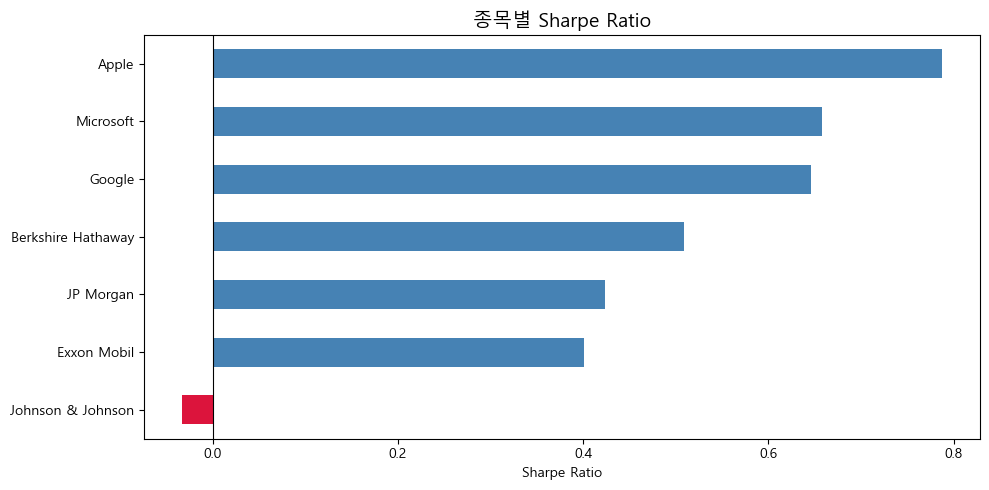

In [5]:
risk_free_rate = 0.05  # 무위험 수익률 5%

sharpe_ratios = (annual_returns - risk_free_rate) / annual_vol

print("=== Sharpe Ratio 순위 ===")
print(sharpe_ratios.sort_values(ascending=False).round(4))

plt.figure(figsize=(10, 5))
sharpe_ratios.sort_values().plot(kind='barh',
    color=['crimson' if x < 0 else 'steelblue' for x in sharpe_ratios.sort_values()])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('종목별 Sharpe Ratio', fontsize=14)
plt.xlabel('Sharpe Ratio')
plt.tight_layout()
plt.savefig('images/sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()